## Problema e pergunta central

**Problema:** Os municípios cearenses apresentam trajetórias distintas de transformação agropecuária ao longo das últimas duas décadas, tanto em sua composição produtiva quanto na importância da agropecuária para a economia local.

**Pergunta central:** Como o perfil agropecuário dos municípios cearenses se transformou entre 2003 e 2024 e como essas mudanças se relacionam com sua estrutura econômica?

Este notebook cobre a parte de **composição produtiva agrícola**: área, produção, rendimento e valor por produto, por município e ao longo do tempo — inclusive qual produto domina a economia agrícola de cada município e se isso mudou entre 2003 e 2024.

## 1. Carga dos dados

### Dicionário de dados

| Coluna | Significado |
|---|---|
| `nivel_territorial_codigo` / `nivel_territorial_nome` | Nível geográfico: N1 Brasil, N3 Ceará, N6 Município |
| `territorio_codigo` | Código IBGE do território |
| `territorio_nome` | Nome do território |
| `ano_codigo` | Ano de referência (2003-2024) |
| `variavel_codigo` / `variavel_nome` | Área colhida, área plantada, quantidade produzida, rendimento médio, valor da produção (fixa por arquivo) |
| `unidade` | Hectares, toneladas, kg/ha ou Mil Reais, conforme a variável |
| `produto_codigo` / `produto_nome` | Lavoura: milho, feijão, mandioca, cana-de-açúcar, banana, castanha de caju, melão |
| `valor` | Valor da variável |

Fonte: IBGE/SIDRA, tabela 5457 (5 recortes). Ceará + 184 municípios + Brasil, 2003-2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

AZUL = "#0B5FA5"
LARANJA = "#F28E2B"

**carregar os 5 arquivos PAM** (área colhida, área plantada, quantidade produzida, rendimento médio, valor da produção) — mesmo schema, cada arquivo tem `variavel_nome` fixa. Concatena tudo num `df` só, igual ideia do PIB (formato longo).

In [2]:
pam_paths = {
    "area_colhida": "../dados/raw/dados_originais/t5457_pam_area_colhida_2003_2024_ce_br.csv",
    "area_plantada": "../dados/raw/dados_originais/t5457_pam_area_plantada_2003_2024_ce_br.csv",
    "quantidade_produzida": "../dados/raw/dados_originais/t5457_pam_quantidade_produzida_2003_2024_ce_br.csv",
    "rendimento_medio": "../dados/raw/dados_originais/t5457_pam_rendimento_medio_2003_2024_ce_br.csv",
    "valor_producao": "../dados/raw/dados_originais/t5457_pam_valor_producao_2003_2024_ce_br.csv",
}

df = pd.concat(
    [pd.read_csv(p, sep=";", encoding="utf-8-sig") for p in pam_paths.values()],
    ignore_index=True
)
df.shape
df.head(10)

,nivel_territorial_codigo,nivel_territorial_nome,territorio_codigo,territorio_nome,ano_codigo,ano_nome,variavel_codigo,variavel_nome,unidade,produto_codigo,produto_nome,valor
0,N1,Brasil,1,Brasil,2003,2003,216,Área colhida,Hectares,40122,Milho (em grão),12965678
1,N1,Brasil,1,Brasil,2004,2004,216,Área colhida,Hectares,40122,Milho (em grão),12410677
2,N1,Brasil,1,Brasil,2005,2005,216,Área colhida,Hectares,40122,Milho (em grão),11549425
3,N1,Brasil,1,Brasil,2006,2006,216,Área colhida,Hectares,40122,Milho (em grão),12613094
4,N1,Brasil,1,Brasil,2007,2007,216,Área colhida,Hectares,40122,Milho (em grão),13767431
5,N1,Brasil,1,Brasil,2008,2008,216,Área colhida,Hectares,40122,Milho (em grão),14444582
6,N1,Brasil,1,Brasil,2009,2009,216,Área colhida,Hectares,40122,Milho (em grão),13654715
7,N1,Brasil,1,Brasil,2010,2010,216,Área colhida,Hectares,40122,Milho (em grão),12678875
8,N1,Brasil,1,Brasil,2011,2011,216,Área colhida,Hectares,40122,Milho (em grão),13218892
9,N1,Brasil,1,Brasil,2012,2012,216,Área colhida,Hectares,40122,Milho (em grão),14198496


In [3]:
df.dtypes

nivel_territorial_codigo    object
nivel_territorial_nome      object
territorio_codigo            int64
territorio_nome             object
ano_codigo                   int64
ano_nome                     int64
variavel_codigo              int64
variavel_nome               object
unidade                     object
produto_codigo               int64
produto_nome                object
valor                       object
dtype: object

In [4]:
df["nivel_territorial_nome"].value_counts()

nivel_territorial_nome
Município               141680
Brasil                     770
Unidade da Federação       770
Name: count, dtype: int64

In [5]:
df["variavel_nome"].value_counts()

variavel_nome
Área colhida                             28644
Área plantada ou destinada à colheita    28644
Quantidade produzida                     28644
Rendimento médio da produção             28644
Valor da produção                        28644
Name: count, dtype: int64

In [6]:
df["produto_nome"].value_counts()

produto_nome
Milho (em grão)     20460
Feijão (em grão)    20460
Mandioca            20460
Cana-de-açúcar      20460
Banana (cacho)      20460
Castanha de caju    20460
Melão               20460
Name: count, dtype: int64

In [7]:
df["ano_codigo"].agg(["min", "max"])

min    2003
max    2024
Name: ano_codigo, dtype: int64

## 2. Limpeza de dados

**Chave primária e duplicatas**

`territorio_codigo` + `ano_codigo` + `produto_codigo` + `variavel_nome`
(diferente do PIB, que não tem `produto_codigo` — PAM quebra por produto agrícola, 7 produtos: milho, feijão, mandioca, cana-de-açúcar, banana, castanha de caju, melão).

Confere se não tem duplicata nessa chave:

In [8]:
chave = ["territorio_codigo", "ano_codigo", "produto_codigo", "variavel_nome"]
df.duplicated(subset=chave).sum()

np.int64(0)

In [9]:
mask = pd.to_numeric(df["valor"], errors="coerce").isna()
mask.sum()
df.loc[mask, "valor"].value_counts()

valor
-    31467
Name: count, dtype: int64

**Símbolo especial SIDRA `-`**

31467 linhas com `"-"`, só nível Município, espalhado em todos os anos (2003-2024) e nas 5 variáveis — diferente do `"..."` do PIB (que era atraso de divulgação, concentrado em 2022-2023). Pelo padrão IBGE, `"-"` = zero exato, não arredondamento: o município não produziu aquele produto naquele ano.

Decisão de limpeza (por variável, não é uma regra única):
- **área colhida, área plantada, quantidade produzida, valor da produção** → `"-"` vira `0` (produção inexistente é zero de verdade).
- **rendimento médio** → `"-"` vira `NaN`, não `0`. Rendimento = produção/área; quando área é zero o rendimento é indefinido (divisão por zero), não nulo. Tratar como `0` sugeriria "produziu com rendimento nulo", o que é diferente de "não produziu".

In [10]:
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

is_rendimento = df["variavel_nome"] == "Rendimento médio da produção"
df.loc[~is_rendimento, "valor"] = df.loc[~is_rendimento, "valor"].fillna(0)

df["valor"].isna().sum()

np.int64(6314)

**Nome do território e coluna redundante**

- `territorio_nome` tem sufixo `" - CE"` só nos municípios — tira pra ficar consistente com Brasil/Ceará.
- `ano_nome` é idêntico a `ano_codigo` (redundante) — confere e descarta.

In [11]:
df["territorio_nome"] = df["territorio_nome"].str.replace(r" - CE$", "", regex=True)

(df["ano_codigo"] != df["ano_nome"]).sum()

np.int64(0)

In [12]:
df = df.drop(columns=["ano_nome"])

## 3. Separação por nível territorial

In [13]:
df_brasil = df[df["nivel_territorial_nome"]=="Brasil"]
df_ce = df[df["nivel_territorial_nome"]=="Unidade da Federação"]
df_mun = df[df["nivel_territorial_nome"]=="Município"]

## 4. Exploração (matplotlib)

**1. Área colhida no Ceará, por produto (2003-2024)**

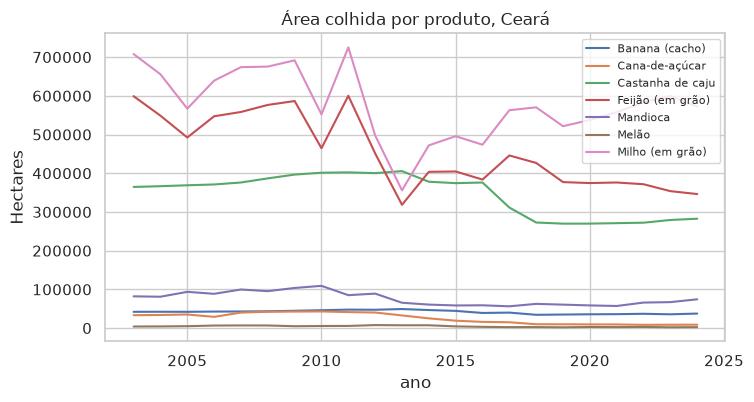

In [14]:
import matplotlib.pyplot as plt

area_ce = df_ce[df_ce["variavel_nome"] == "Área colhida"]

for produto, grupo in area_ce.groupby("produto_nome"):
    plt.plot(grupo["ano_codigo"], grupo["valor"], label=produto)

plt.title("Área colhida por produto, Ceará")
plt.xlabel("ano")
plt.ylabel("Hectares")
plt.legend(fontsize=8)
plt.show()

**2. Quantidade produzida por produto, Ceará, ano mais recente (2024)**

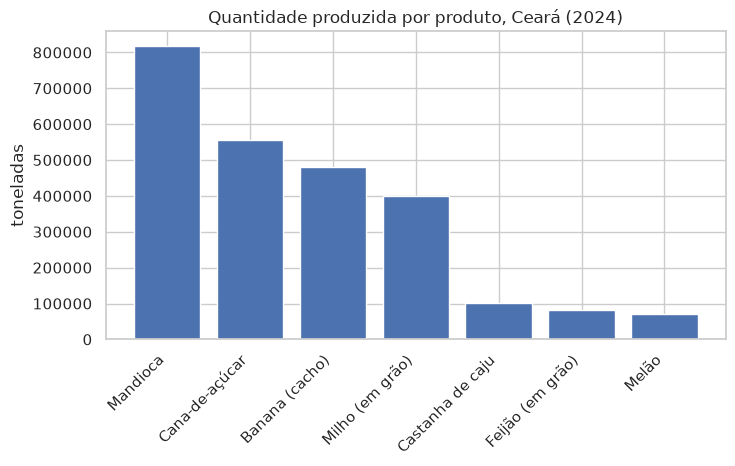

In [15]:
ano_recente = df["ano_codigo"].max()

qtd_ce_recente = df_ce[
    (df_ce["variavel_nome"] == "Quantidade produzida") &
    (df_ce["ano_codigo"] == ano_recente)
].sort_values("valor", ascending=False)

plt.bar(qtd_ce_recente["produto_nome"], qtd_ce_recente["valor"])
plt.title(f"Quantidade produzida por produto, Ceará ({ano_recente})")
plt.ylabel("toneladas")
plt.xticks(rotation=45, ha="right")
plt.show()

**3. Rendimento médio por produto ao longo do tempo, Ceará**

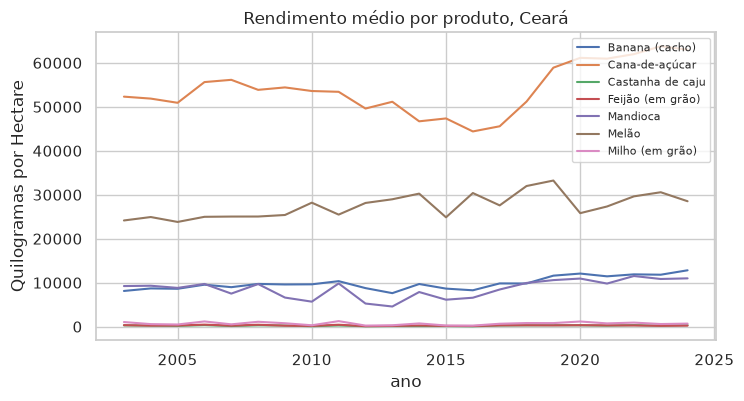

In [16]:
rendimento_ce = df_ce[df_ce["variavel_nome"] == "Rendimento médio da produção"].dropna(subset=["valor"])

for produto, grupo in rendimento_ce.groupby("produto_nome"):
    plt.plot(grupo["ano_codigo"], grupo["valor"], label=produto)

plt.title("Rendimento médio por produto, Ceará")
plt.xlabel("ano")
plt.ylabel(rendimento_ce["unidade"].iloc[0])
plt.legend(fontsize=8)
plt.show()

**4. Top 10 municípios por quantidade produzida de milho (ano mais recente)**

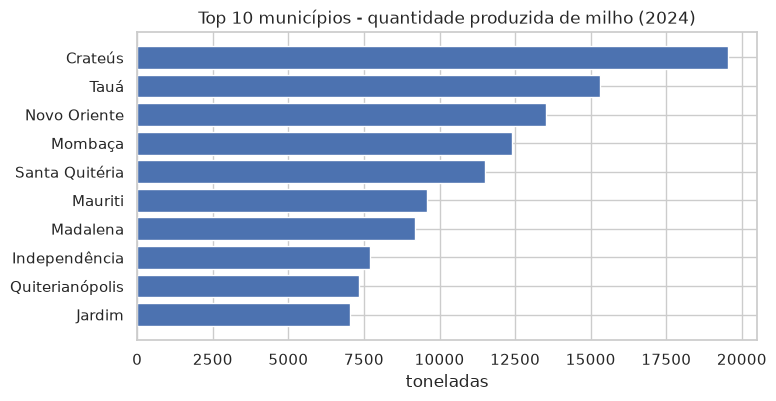

In [17]:
milho_mun_recente = df_mun[
    (df_mun["variavel_nome"] == "Quantidade produzida") &
    (df_mun["produto_nome"] == "Milho (em grão)") &
    (df_mun["ano_codigo"] == ano_recente)
].sort_values("valor", ascending=False).head(10)

plt.barh(milho_mun_recente["territorio_nome"], milho_mun_recente["valor"])
plt.title(f"Top 10 municípios - quantidade produzida de milho ({ano_recente})")
plt.xlabel("toneladas")
plt.gca().invert_yaxis()
plt.show()

**5. Distribuição da área colhida de mandioca entre municípios (ano mais recente)**

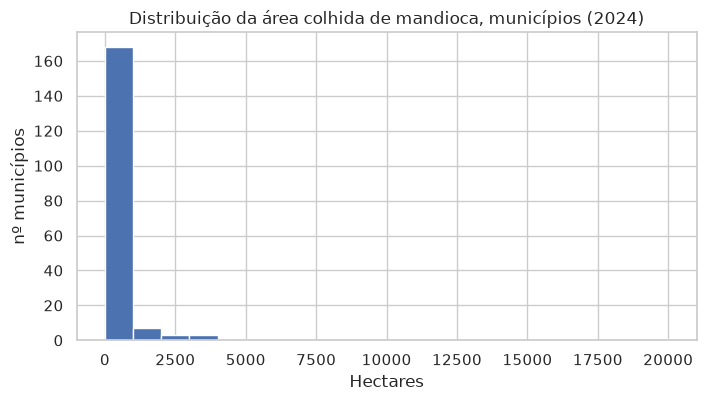

In [18]:
mandioca_area_mun = df_mun[
    (df_mun["variavel_nome"] == "Área colhida") &
    (df_mun["produto_nome"] == "Mandioca") &
    (df_mun["ano_codigo"] == ano_recente)
]["valor"]

plt.hist(mandioca_area_mun, bins=20)
plt.title(f"Distribuição da área colhida de mandioca, municípios ({ano_recente})")
plt.xlabel("Hectares")
plt.ylabel("nº municípios")
plt.show()

**6. Valor da produção agrícola, Ceará, por produto ao longo do tempo**

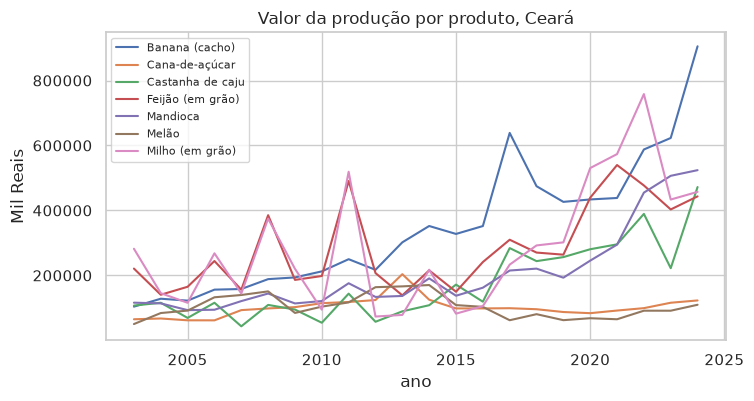

In [19]:
valor_ce = df_ce[df_ce["variavel_nome"] == "Valor da produção"]

for produto, grupo in valor_ce.groupby("produto_nome"):
    plt.plot(grupo["ano_codigo"], grupo["valor"], label=produto)

plt.title("Valor da produção por produto, Ceará")
plt.xlabel("ano")
plt.ylabel(valor_ce["unidade"].iloc[0])
plt.legend(fontsize=8)
plt.show()

**7. Perda de área (plantada não colhida), por produto, Ceará (ano mais recente)**

`(área plantada − área colhida) / área plantada` — indica frustração de safra (seca, praga etc).

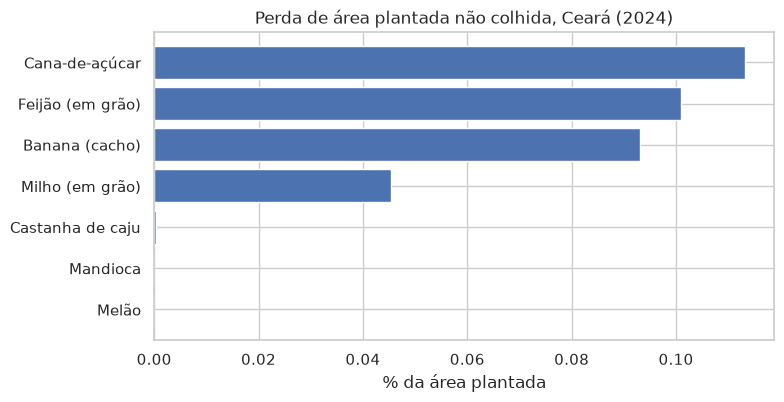

In [20]:
ce_recente_wide = df_ce[df_ce["ano_codigo"] == ano_recente].pivot_table(
    index="produto_nome", columns="variavel_nome", values="valor"
)

perda_area = (
    (ce_recente_wide["Área plantada ou destinada à colheita"] - ce_recente_wide["Área colhida"])
    / ce_recente_wide["Área plantada ou destinada à colheita"] * 100
).sort_values(ascending=False)

plt.barh(perda_area.index, perda_area.values)
plt.title(f"Perda de área plantada não colhida, Ceará ({ano_recente})")
plt.xlabel("% da área plantada")
plt.gca().invert_yaxis()
plt.show()

**8. Top 10 municípios por rendimento médio de milho (ano mais recente)**

Produtividade, não volume — município pequeno pode ter rendimento maior que município grande.

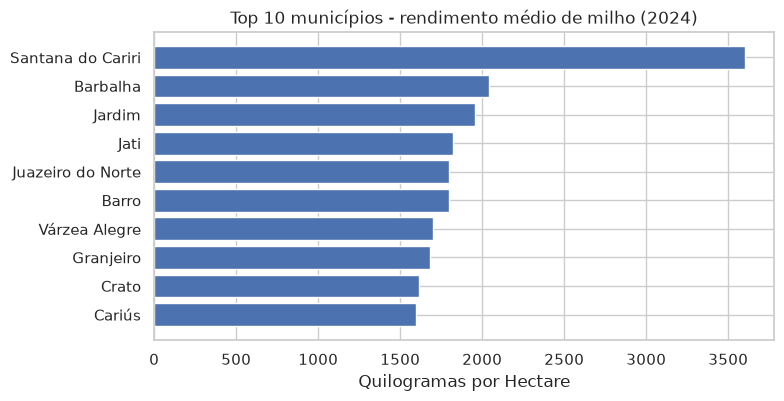

In [21]:
rendimento_milho_mun = df_mun[
    (df_mun["variavel_nome"] == "Rendimento médio da produção") &
    (df_mun["produto_nome"] == "Milho (em grão)") &
    (df_mun["ano_codigo"] == ano_recente)
].dropna(subset=["valor"]).sort_values("valor", ascending=False).head(10)

plt.barh(rendimento_milho_mun["territorio_nome"], rendimento_milho_mun["valor"])
plt.title(f"Top 10 municípios - rendimento médio de milho ({ano_recente})")
plt.xlabel(rendimento_milho_mun["unidade"].iloc[0])
plt.gca().invert_yaxis()
plt.show()

## 5. Qualidade dos dados, forma da distribuição e estatística

**9. Outliers — quantidade produzida de milho entre municípios (ano mais recente), boxplot + IQR**

/tmp/ipykernel_91739/1613635890.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(milho_qtd_mun["valor"], vert=False)


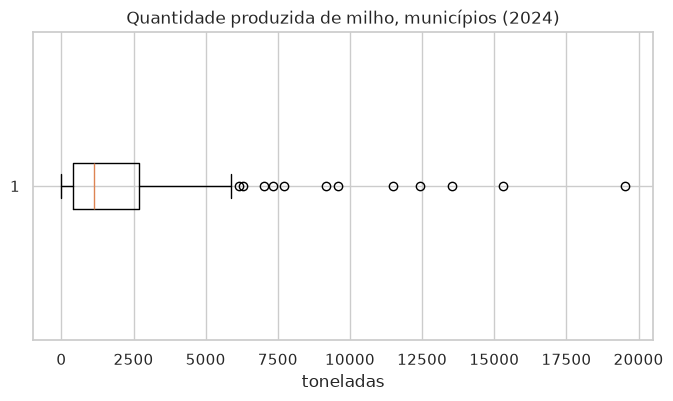

,territorio_nome,valor
58431,Crateús,19530.0
61115,Tauá,15300.0
60059,Novo Oriente,13533.0
59861,Mombaça,12410.0
60851,Santa Quitéria,11500.0
59729,Mauriti,9600.0
59597,Madalena,9180.0
59047,Independência,7700.0
60587,Quiterianópolis,7332.0
59443,Jardim,7031.0


In [22]:
milho_qtd_mun = df_mun[
    (df_mun["variavel_nome"] == "Quantidade produzida") &
    (df_mun["produto_nome"] == "Milho (em grão)") &
    (df_mun["ano_codigo"] == ano_recente)
]

plt.boxplot(milho_qtd_mun["valor"], vert=False)
plt.title(f"Quantidade produzida de milho, municípios ({ano_recente})")
plt.xlabel("toneladas")
plt.show()

q1, q3 = milho_qtd_mun["valor"].quantile([0.25, 0.75])
iqr = q3 - q1
limite = q3 + 1.5 * iqr

outliers = milho_qtd_mun[milho_qtd_mun["valor"] > limite].sort_values("valor", ascending=False)
outliers[["territorio_nome", "valor"]]

**10. Consistência lógica: área colhida não pode ser maior que área plantada**

Isso não é outlier estatístico, é erro de dado se acontecer (fisicamente impossível colher mais do que plantou).

In [23]:
area_wide = df_mun.pivot_table(
    index=["territorio_nome", "ano_codigo", "produto_nome"],
    columns="variavel_nome", values="valor"
)

inconsistentes = area_wide[area_wide["Área colhida"] > area_wide["Área plantada ou destinada à colheita"]]
len(inconsistentes)
inconsistentes[["Área colhida", "Área plantada ou destinada à colheita"]]

,,variavel_nome,Área colhida,Área plantada ou destinada à colheita
territorio_nome,ano_codigo,produto_nome,,


**11. Estatística descritiva (quartis, média, desvio) — quantidade produzida de milho, municípios**

In [24]:
milho_qtd_mun["valor"].describe()

count      184.000000
mean      2166.635870
std       2884.084492
min          0.000000
25%        392.000000
50%       1125.000000
75%       2681.000000
max      19530.000000
Name: valor, dtype: float64

In [25]:
milho_qtd_mun["valor"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.10      148.10
0.25      392.00
0.50     1125.00
0.75     2681.00
0.90     5400.00
0.95     6921.35
0.99    13833.39
Name: valor, dtype: float64

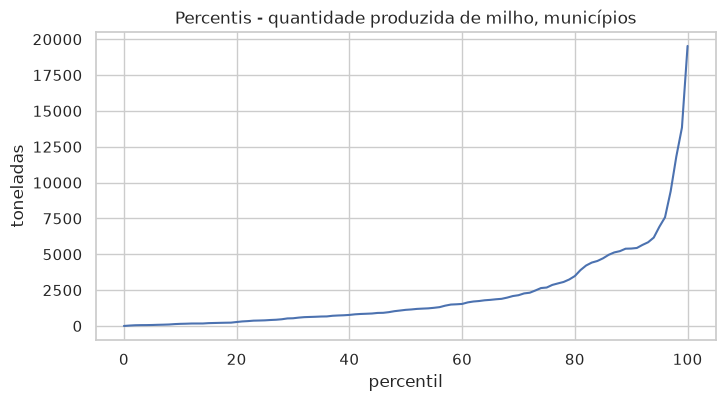

In [26]:
percentis = np.arange(0, 101)
valores_percentis = milho_qtd_mun["valor"].quantile(percentis / 100)

plt.plot(percentis, valores_percentis)
plt.title("Percentis - quantidade produzida de milho, municípios")
plt.xlabel("percentil")
plt.ylabel("toneladas")
plt.show()

**12. Coeficiente de variação (desvio padrão / média) da quantidade produzida, por produto**

Compara dispersão entre municípios mesmo com produtos de escalas diferentes (milho em toneladas vs castanha de caju em toneladas, ordens de grandeza distintas).

In [27]:
qtd_mun_recente = df_mun[
    (df_mun["variavel_nome"] == "Quantidade produzida") &
    (df_mun["ano_codigo"] == ano_recente)
]

cv_por_produto = qtd_mun_recente.groupby("produto_nome")["valor"].agg(lambda s: s.std() / s.mean())
cv_por_produto.sort_values(ascending=False)

produto_nome
Melão               7.991313
Cana-de-açúcar      5.175763
Mandioca            4.351328
Banana (cacho)      3.200667
Castanha de caju    3.170072
Feijão (em grão)    1.399194
Milho (em grão)     1.331135
Name: valor, dtype: float64

**13. Abrangência territorial — quantos municípios produzem cada produto (ano mais recente)**

Diferente de "quanto produz": aqui é "quantos dos 184 municípios plantam".

In [28]:
abrangencia = qtd_mun_recente[qtd_mun_recente["valor"] > 0].groupby("produto_nome")["territorio_nome"].nunique()
abrangencia.sort_values(ascending=False)

produto_nome
Feijão (em grão)    183
Milho (em grão)     183
Mandioca            174
Castanha de caju    163
Banana (cacho)      162
Cana-de-açúcar      113
Melão                14
Name: territorio_nome, dtype: int64

**14. Concentração — quanto os top 10 municípios respondem da produção de milho (ano mais recente)**

In [29]:
total_milho = milho_qtd_mun["valor"].sum()
top10_milho = milho_qtd_mun.sort_values("valor", ascending=False).head(10)["valor"].sum()

top10_milho / total_milho * 100

np.float64(28.37398190442506)

**15. Correlação interna: área colhida × rendimento × quantidade produzida (milho, municípios)**

In [30]:
milho_wide = df_mun[
    (df_mun["produto_nome"] == "Milho (em grão)") &
    (df_mun["ano_codigo"] == ano_recente)
].pivot_table(index="territorio_nome", columns="variavel_nome", values="valor")

milho_wide[["Área colhida", "Rendimento médio da produção", "Quantidade produzida"]].corr()

variavel_nome,Área colhida,Rendimento médio da produção,Quantidade produzida
variavel_nome,,,
Área colhida,1.000000,0.012554,0.849588
Rendimento médio da produção,0.012554,1.000000,0.378050
Quantidade produzida,0.849588,0.378050,1.000000


**16. Moda e média aparada — quantidade produzida de milho, municípios**

In [31]:
medidas_centralidade = pd.DataFrame({
    "Medida": ["Média", "Mediana", "Moda", "Média aparada (10% em cada cauda)"],
    "Quantidade produzida de milho (t)": [
        milho_qtd_mun["valor"].mean(),
        milho_qtd_mun["valor"].median(),
        milho_qtd_mun["valor"].mode().iloc[0],
        stats.trim_mean(milho_qtd_mun["valor"], 0.10),
    ],
})

medidas_centralidade.round(2)

,Medida,Quantidade produzida de milho (t)
0,Média,2166.64
1,Mediana,1125.00
2,Moda,172.00
3,Média aparada (10% em cada cauda),1607.61


**17. Intervalo interquartil (IIQ) — quantidade produzida de milho, municípios**

In [32]:
q1, q3 = milho_qtd_mun["valor"].quantile([0.25, 0.75])
iiq = q3 - q1
iiq

2289.0

**18. Média simples vs. média ponderada — rendimento médio de milho entre municípios**

Pondera pela área colhida: município que planta muito pesa mais que município que planta pouco. Compara com o valor calculado direto pro Ceará (que não é a média dos municípios).

In [33]:
milho_wide_validos = milho_wide.dropna(subset=["Rendimento médio da produção"])

media_simples = milho_wide_validos["Rendimento médio da produção"].mean()
media_ponderada = np.average(
    milho_wide_validos["Rendimento médio da produção"],
    weights=milho_wide_validos["Área colhida"],
)
valor_ceara = rendimento_ce.loc[
    (rendimento_ce["produto_nome"] == "Milho (em grão)") & (rendimento_ce["ano_codigo"] == ano_recente),
    "valor"
].iloc[0]

comparacao_medias = pd.DataFrame({
    "Cálculo": [
        "Média simples entre municípios",
        "Média entre municípios ponderada pela área colhida",
        "Valor agregado do Ceará (direto na tabela)",
    ],
    "Rendimento médio de milho": [media_simples, media_ponderada, valor_ceara],
})

comparacao_medias.round(2)

,Cálculo,Rendimento médio de milho
0,Média simples entre municípios,689.78
1,Média entre municípios ponderada pela área col...,696.76
2,Valor agregado do Ceará (direto na tabela),697.00


**19. Assimetria — quantidade produzida de milho, municípios**

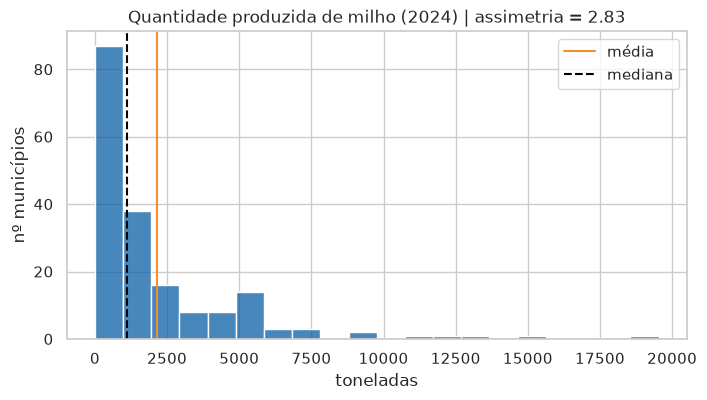

In [34]:
ax = sns.histplot(milho_qtd_mun["valor"], color=AZUL, bins=20)
ax.axvline(milho_qtd_mun["valor"].mean(), color=LARANJA, label="média")
ax.axvline(milho_qtd_mun["valor"].median(), color="black", linestyle="--", label="mediana")
ax.set(
    title=f"Quantidade produzida de milho ({ano_recente}) | assimetria = {milho_qtd_mun['valor'].skew():.2f}",
    xlabel="toneladas", ylabel="nº municípios",
)
ax.legend()
plt.show()

**20. ECDF — quantidade produzida de milho, municípios**

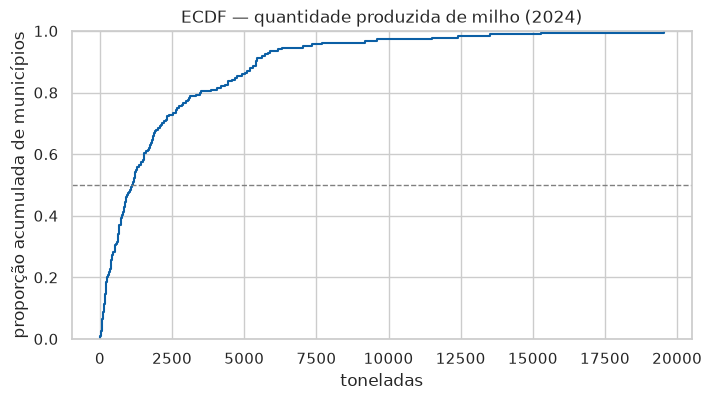

In [35]:
sns.ecdfplot(milho_qtd_mun["valor"], color=AZUL)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.title(f"ECDF — quantidade produzida de milho ({ano_recente})")
plt.xlabel("toneladas")
plt.ylabel("proporção acumulada de municípios")
plt.show()

**21. CCDF em escala log-log — concentração da produção de milho**

Exclui municípios com produção zero (log de zero não existe). Reta aproximada no log-log é indício de cauda pesada (poucos municípios concentram a maior parte da produção).

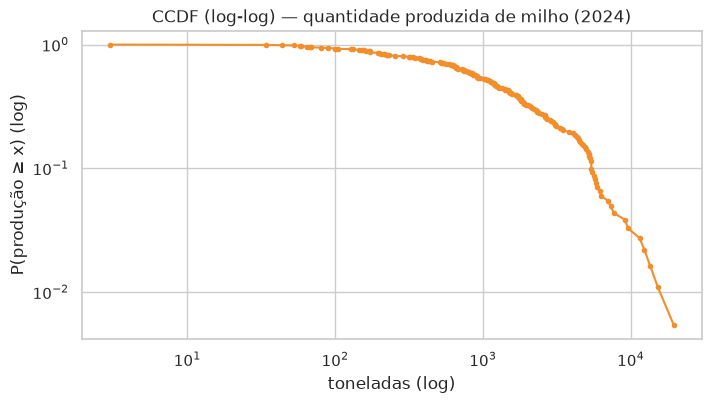

In [36]:
producao_positiva = milho_qtd_mun.loc[milho_qtd_mun["valor"] > 0, "valor"]
valores_ordenados = np.sort(producao_positiva.unique())
ccdf = [(producao_positiva >= v).mean() for v in valores_ordenados]

plt.loglog(valores_ordenados, ccdf, "o-", color=LARANJA, markersize=3)
plt.title(f"CCDF (log-log) — quantidade produzida de milho ({ano_recente})")
plt.xlabel("toneladas (log)")
plt.ylabel("P(produção ≥ x) (log)")
plt.show()

**22. Outliers por z-score (|z| > 3) — comparar com a regra IIQ do item 9**

In [37]:
z_scores = stats.zscore(milho_qtd_mun["valor"])
outliers_z = milho_qtd_mun[np.abs(z_scores) > 3].sort_values("valor", ascending=False)

len(outliers_z)
outliers_z[["territorio_nome", "valor"]]

,territorio_nome,valor
58431,Crateús,19530.0
61115,Tauá,15300.0
60059,Novo Oriente,13533.0
59861,Mombaça,12410.0
60851,Santa Quitéria,11500.0


**23. Normalização — MinMax vs Standard vs Robust (quantidade produzida de milho)**

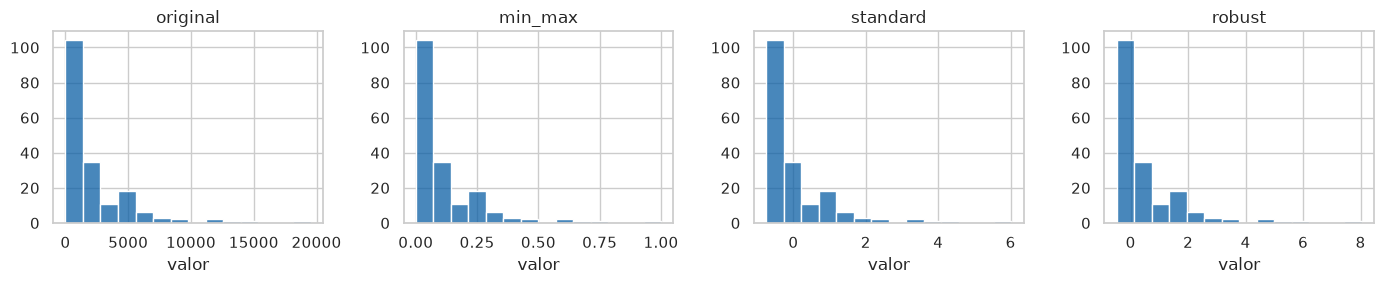

In [38]:
valor = milho_qtd_mun["valor"]

escalas = pd.DataFrame({
    "original": valor,
    "min_max": (valor - valor.min()) / (valor.max() - valor.min()),
    "standard": (valor - valor.mean()) / valor.std(),
    "robust": (valor - valor.median()) / iiq,
})

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for coluna, ax in zip(escalas.columns, axes):
    sns.histplot(escalas[coluna], bins=14, color=AZUL, ax=ax)
    ax.set(title=coluna, xlabel="valor", ylabel="")
plt.tight_layout()
plt.show()

**24. Pearson vs Spearman + heatmap — área colhida, rendimento e quantidade (milho)**

Complementa a correlação do item 15 (só Pearson) com Spearman e visual em heatmap.

In [39]:
colunas_milho = ["Área colhida", "Rendimento médio da produção", "Quantidade produzida"]

pearson_vs_spearman = pd.DataFrame({
    "Pearson": milho_wide[colunas_milho].corr(method="pearson").loc["Quantidade produzida"],
    "Spearman": milho_wide[colunas_milho].corr(method="spearman").loc["Quantidade produzida"],
})

pearson_vs_spearman.round(3)

,Pearson,Spearman
variavel_nome,,
Área colhida,0.850,0.850
Rendimento médio da produção,0.378,0.598
Quantidade produzida,1.000,1.000


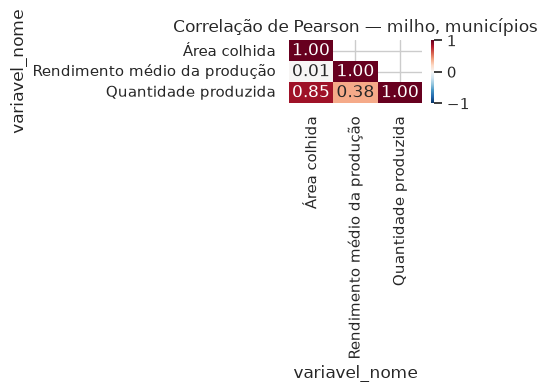

In [40]:
corr = milho_wide[colunas_milho].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação de Pearson — milho, municípios")
plt.tight_layout()
plt.show()

**25. Pairplot — área colhida, rendimento e quantidade (milho, municípios)**

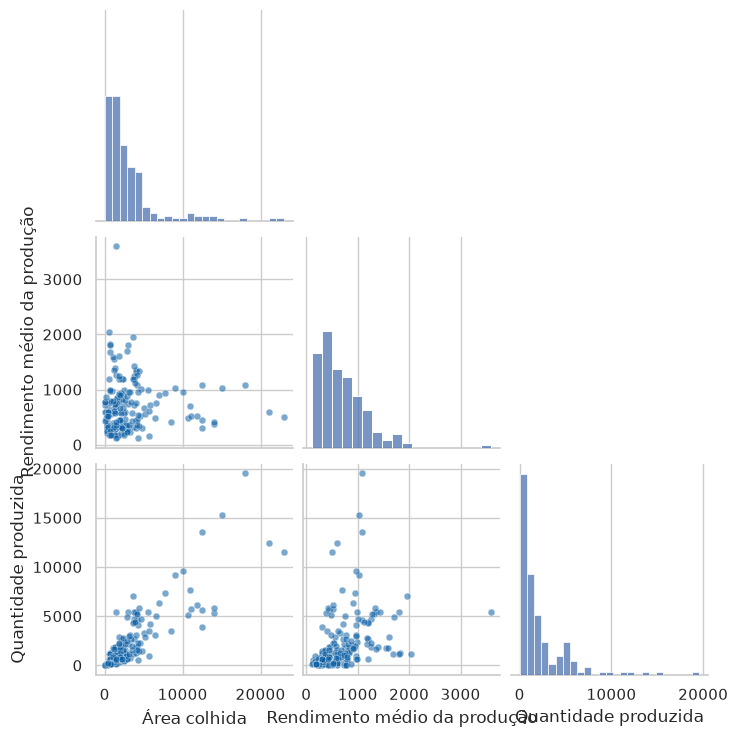

In [41]:
sns.pairplot(milho_wide[colunas_milho], corner=True, diag_kind="hist", plot_kws={"alpha": 0.55, "s": 24, "color": AZUL})
plt.show()

**26. Distribuição Binomial — quantos produtos cada município cultiva (de 7 possíveis)**

Cada produto é uma "tentativa": o município cultiva (sucesso) ou não. $n=7$ produtos, $p$ = proporção média de municípios que cultivam cada produto. Compara a distribuição observada (quantos municípios cultivam 0, 1, 2... produtos) com a Binomial teórica.

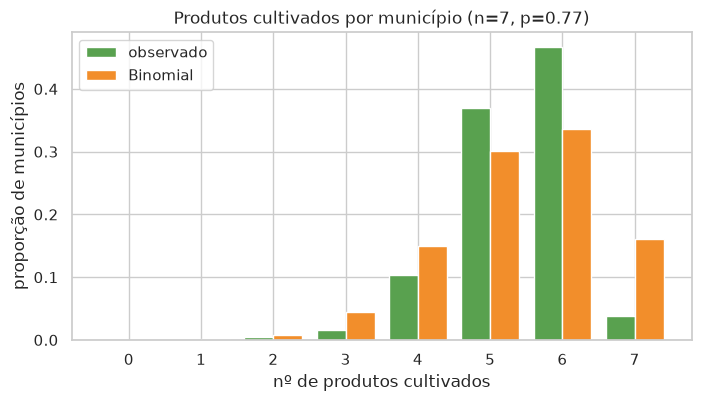

In [42]:
n_produtos = df["produto_nome"].nunique()

produtos_por_municipio = (
    qtd_mun_recente.assign(cultivou=qtd_mun_recente["valor"] > 0)
    .groupby("territorio_nome")["cultivou"].sum()
)

p_cultivo = produtos_por_municipio.mean() / n_produtos
k_binomial = np.arange(n_produtos + 1)

frequencia_observada = produtos_por_municipio.value_counts(normalize=True).reindex(k_binomial, fill_value=0)

plt.bar(k_binomial - 0.2, frequencia_observada, width=0.4, label="observado", color="#59A14F")
plt.bar(k_binomial + 0.2, stats.binom.pmf(k_binomial, n=n_produtos, p=p_cultivo), width=0.4, label="Binomial", color=LARANJA)
plt.xlabel("nº de produtos cultivados")
plt.ylabel("proporção de municípios")
plt.title(f"Produtos cultivados por município (n={n_produtos}, p={p_cultivo:.2f})")
plt.legend()
plt.show()

**27. Distribuição de Poisson — mesmo dado, pra comparar**

Poisson tem suporte infinito (0 a ∞); aqui o máximo real é 7 (só existem 7 produtos). Por isso é uma aproximação pior que a Binomial pra essa variável — mostramos pra comparar, não porque seja o modelo certo.

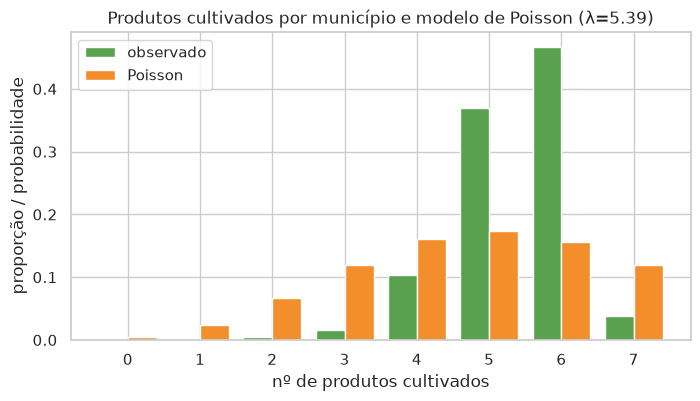

In [43]:
lambda_produtos = produtos_por_municipio.mean()

plt.bar(k_binomial - 0.2, frequencia_observada, width=0.4, label="observado", color="#59A14F")
plt.bar(k_binomial + 0.2, stats.poisson.pmf(k_binomial, mu=lambda_produtos), width=0.4, label="Poisson", color=LARANJA)
plt.xlabel("nº de produtos cultivados")
plt.ylabel("proporção / probabilidade")
plt.title(f"Produtos cultivados por município e modelo de Poisson (λ={lambda_produtos:.2f})")
plt.legend()
plt.show()

## Resumo

| Técnica | Onde usamos | Cuidado |
|---|---|---|
| Média, mediana, moda, média aparada | Item 11, 16 | Moda aqui é útil (muitos zeros — municípios sem produção) |
| Média ponderada | Item 18 | Peso pela área, não simples contagem de municípios |
| Quartis, percentis, IIQ | Item 11, 17 | Método de interpolação pode mudar o resultado |
| Boxplot + regra IIQ | Item 9 | Sinaliza, não decide sozinho se é erro |
| Consistência lógica (área colhida ≤ plantada) | Item 10 | Não é outlier estatístico, é erro de dado se ocorrer |
| z-score | Item 22 | Sensível quando a distribuição já é assimétrica |
| Assimetria (`skew`) | Item 19 | Não substitui olhar o histograma |
| ECDF | Item 20 | Outra forma de ver os percentis |
| CCDF log-log | Item 21 | Reta no gráfico é indício, não prova de Pareto |
| Normalização (MinMax/Standard/Robust) | Item 23 | Muda escala, não muda outliers nem forma |
| Pearson vs Spearman | Item 24 | Divergência = relação não-linear |
| Heatmap / Pairplot | Item 24, 25 | Correlação não é causalidade |
| Binomial | Item 26 | n=7 (produtos), bom encaixe: variável tem teto natural |
| Poisson | Item 27 | Suporte infinito, encaixe pior que Binomial pra essa variável (mostrado por comparação) |
| Exponencial | não aplicada | Modela tempo contínuo entre eventos; nosso dado é anual agregado, não tem essa granularidade |

## 6. Salvar em `processed`

`df` já limpo (símbolo especial tratado, nome sem sufixo, coluna redundante removida) — salva em parquet, não mexe no `raw`.

**28. Transformação da composição produtiva — produto dominante por município, 2003 vs 2024**

Pra cada município, qual dos 7 produtos tem maior valor da produção — e se esse "produto dominante" mudou entre 2003 e 2024. Isso responde diretamente à pergunta central: como a composição produtiva mudou, não só quanto cresceu.

In [44]:
valor_mun = df_mun[df_mun["variavel_nome"] == "Valor da produção"]

def produto_dominante(ano):
    sub = valor_mun[valor_mun["ano_codigo"] == ano]
    idx = sub.groupby("territorio_nome")["valor"].idxmax()
    return sub.loc[idx].set_index("territorio_nome")["produto_nome"]

dominante_2003 = produto_dominante(2003)
dominante_recente = produto_dominante(ano_recente)

composicao = pd.DataFrame({"2003": dominante_2003, ano_recente: dominante_recente})
mudou = composicao["2003"] != composicao[ano_recente]

print(f"municípios que mudaram o produto dominante: {mudou.sum()} de {len(composicao)} ({mudou.mean()*100:.1f}%)")
composicao[mudou].head(15)

municípios que mudaram o produto dominante: 86 de 184 (46.7%)


,2003,2024
territorio_nome,,
Abaiara,Milho (em grão),Banana (cacho)
Acarape,Cana-de-açúcar,Castanha de caju
Acaraú,Castanha de caju,Banana (cacho)
Acopiara,Feijão (em grão),Milho (em grão)
Alto Santo,Feijão (em grão),Castanha de caju
Apuiarés,Feijão (em grão),Milho (em grão)
Aquiraz,Cana-de-açúcar,Mandioca
Aracoiaba,Milho (em grão),Feijão (em grão)
Arneiroz,Feijão (em grão),Milho (em grão)


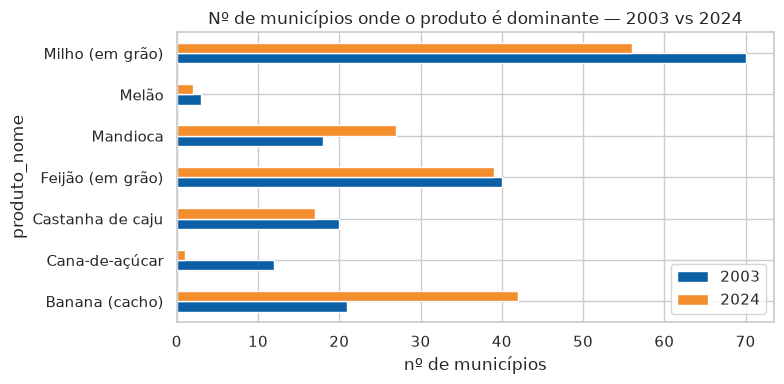

In [45]:
contagem_2003 = dominante_2003.value_counts()
contagem_recente = dominante_recente.value_counts()

comparacao_contagem = pd.DataFrame({"2003": contagem_2003, ano_recente: contagem_recente}).fillna(0)

comparacao_contagem.plot(kind="barh", color=[AZUL, LARANJA])
plt.title("Nº de municípios onde o produto é dominante — 2003 vs " + str(ano_recente))
plt.xlabel("nº de municípios")
plt.tight_layout()
plt.show()

In [46]:
df.to_parquet("../dados/processed/pam_lavouras.parquet", index=False)